In [1]:
# Cell 1 - Imports and Setup
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import json
import warnings
warnings.filterwarnings("ignore")

while not os.path.exists(os.path.join(os.getcwd(), "data")):
    os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: e:\causal-fairness-credit-scoring\causal-fairness-credit-scoring


In [2]:
# Cell 2 - Load Data
df = pd.read_csv("data/german_credit_data.csv")
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Risk unique:", df["Risk"].unique())
print("Sex unique:", df["Sex"].unique())

Shape: (1000, 11)
Columns: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk', 'Age_group']
Risk unique: ['good' 'bad']
Sex unique: ['male' 'female']


In [3]:
# Cell 3 - Fairness Functions
def demographic_parity(y_pred, sex):
    y_pred = np.array([str(p) for p in y_pred])
    sex    = np.array([str(s) for s in sex])
    results = pd.DataFrame({"prediction": y_pred, "Sex": sex})
    rates = results.groupby("Sex")["prediction"].apply(
        lambda x: (x == "good").mean()
    )
    gap = abs(rates["male"] - rates["female"])
    return rates, gap

def equal_opportunity(y_true, y_pred, sex):
    y_true = np.array([str(v) for v in y_true])
    y_pred = np.array([str(p) for p in y_pred])
    sex    = np.array([str(s) for s in sex])
    results = pd.DataFrame({
        "actual":     y_true,
        "prediction": y_pred,
        "Sex":        sex
    })
    tpr = {}
    for group in results["Sex"].unique():
        subset   = results[results["Sex"] == group]
        positive = subset[subset["actual"] == "good"]
        tpr[group] = (positive["prediction"] == "good").mean() if len(positive) > 0 else 0.0
    gap = abs(tpr.get("male", 0) - tpr.get("female", 0))
    return tpr, gap

def predictive_parity(y_true, y_pred, sex):
    y_true = np.array([str(v) for v in y_true])
    y_pred = np.array([str(p) for p in y_pred])
    sex    = np.array([str(s) for s in sex])
    results = pd.DataFrame({
        "actual":     y_true,
        "prediction": y_pred,
        "Sex":        sex
    })
    precision = {}
    for group in results["Sex"].unique():
        subset = results[results["Sex"] == group]
        predicted_pos = subset[subset["prediction"] == "good"]
        precision[group] = (predicted_pos["actual"] == "good").mean() if len(predicted_pos) > 0 else 0.0
    return precision

print("Fairness functions ready.")

Fairness functions ready.


In [4]:
# Cell 4 - Prepare Data and Split
sex_col = df["Sex"].copy()
y       = df["Risk"]
X       = df.drop(columns=["Risk", "Sex", "Age_group"], errors="ignore")
X_encoded = pd.get_dummies(X, drop_first=True)

print("Features:", X_encoded.shape[1])
print("Columns:", X_encoded.columns.tolist())

X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X_encoded, y, sex_col,
    test_size=0.2, random_state=42, stratify=y
)

# Reset indices
y_test_r   = np.array([str(v) for v in y_test.reset_index(drop=True)])
sex_test_r = np.array([str(s) for s in sex_test.reset_index(drop=True)])

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_test_r unique:", np.unique(y_test_r))
print("sex_test_r unique:", np.unique(sex_test_r))

Features: 18
Columns: ['Age', 'Job', 'Credit amount', 'Duration', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_moderate', 'Checking account_rich', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']
X_train: (800, 18)
X_test: (200, 18)
y_test_r unique: ['bad' 'good']
sex_test_r unique: ['female' 'male']


In [5]:
# Cell 5 - Preprocess
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_proc = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_proc  = scaler.transform(imputer.transform(X_test))

print("NaN in X_train_proc:", np.isnan(X_train_proc).sum())
print("NaN in X_test_proc:", np.isnan(X_test_proc).sum())
print("X_train_proc shape:", X_train_proc.shape)

NaN in X_train_proc: 0
NaN in X_test_proc: 0
X_train_proc shape: (800, 18)


In [6]:
# Cell 6 - Baseline Model
baseline = LogisticRegression(max_iter=2000, random_state=42, solver="saga")
baseline.fit(X_train_proc, y_train)

y_pred_baseline = np.array([str(p) for p in baseline.predict(X_test_proc)])
baseline_acc    = accuracy_score(y_test_r, y_pred_baseline)

print(f"Baseline Accuracy     : {baseline_acc:.4f}")
print(f"y_pred_baseline unique: {np.unique(y_pred_baseline)}")

base_rates, base_gap = demographic_parity(y_pred_baseline, sex_test_r)
base_tpr,   base_eo  = equal_opportunity(y_test_r, y_pred_baseline, sex_test_r)

print(f"\nBaseline Parity Gap   : {base_gap:.4f}")
print(f"Baseline EO Gap       : {base_eo:.4f}")
print(f"Approval rates:\n{base_rates}")

Baseline Accuracy     : 0.6900
y_pred_baseline unique: ['bad' 'good']

Baseline Parity Gap   : 0.0381
Baseline EO Gap       : 0.0100
Approval rates:
Sex
female    0.833333
male      0.871429
Name: prediction, dtype: float64


In [7]:
# Cell 7 - Fair Model (Threshold Adjustment)
baseline_probs = baseline.predict_proba(X_test_proc)
good_idx       = list(baseline.classes_).index("good")
probs          = baseline_probs[:, good_idx]

female_threshold = 0.45
male_threshold   = 0.50

y_pred_fair = np.array([
    "good" if (
        (sex_test_r[i] == "female" and probs[i] >= female_threshold) or
        (sex_test_r[i] == "male"   and probs[i] >= male_threshold)
    ) else "bad"
    for i in range(len(probs))
])

fair_acc = accuracy_score(y_test_r, y_pred_fair)
fair_rates, fair_gap = demographic_parity(y_pred_fair, sex_test_r)
fair_tpr,   fair_eo  = equal_opportunity(y_test_r, y_pred_fair, sex_test_r)

print(f"Fair Model Accuracy   : {fair_acc:.4f}")
print(f"Fair Parity Gap       : {fair_gap:.4f}")
print(f"Fair EO Gap           : {fair_eo:.4f}")
print(f"Approval rates:\n{fair_rates}")

Fair Model Accuracy   : 0.6800
Fair Parity Gap       : 0.0286
Fair EO Gap           : 0.0350
Approval rates:
Sex
female    0.900000
male      0.871429
Name: prediction, dtype: float64


In [8]:
# Cell 8 - Causal Model 1 (Remove Sex column)
X_c1 = X_encoded.drop(columns=["Sex_male"], errors="ignore")

X_train_c1, X_test_c1, y_train_c1, y_test_c1, sex_train_c1, sex_test_c1 = train_test_split(
    X_c1, y, sex_col, test_size=0.2, random_state=42, stratify=y
)

imp_c1 = SimpleImputer(strategy="median")
sc_c1  = StandardScaler()
X_train_c1_proc = sc_c1.fit_transform(imp_c1.fit_transform(X_train_c1))
X_test_c1_proc  = sc_c1.transform(imp_c1.transform(X_test_c1))

model_c1 = LogisticRegression(max_iter=2000, random_state=42, solver="saga")
model_c1.fit(X_train_c1_proc, y_train_c1)
y_pred_c1 = np.array([str(p) for p in model_c1.predict(X_test_c1_proc)])
acc_c1    = accuracy_score(
    np.array([str(v) for v in y_test_c1.reset_index(drop=True)]),
    y_pred_c1
)

sex_test_c1_r   = np.array([str(s) for s in sex_test_c1.reset_index(drop=True)])
y_test_c1_r     = np.array([str(v) for v in y_test_c1.reset_index(drop=True)])
dp_rates_c1, dp_gap_c1 = demographic_parity(y_pred_c1, sex_test_c1_r)
eo_tpr_c1,   eo_gap_c1 = equal_opportunity(y_test_c1_r, y_pred_c1, sex_test_c1_r)

print(f"Causal Model 1 Accuracy : {acc_c1:.4f}")
print(f"Parity Gap              : {dp_gap_c1:.4f}")
print(f"EO Gap                  : {eo_gap_c1:.4f}")

Causal Model 1 Accuracy : 0.6900
Parity Gap              : 0.0381
EO Gap                  : 0.0100


In [9]:
# Cell 9 - Causal Model 2 (Remove Sex + Proxy columns)
proxy_cols = ["Sex_male", "Purpose_car", "Purpose_education"]
X_c2 = X_encoded.drop(columns=proxy_cols, errors="ignore")

X_train_c2, X_test_c2, y_train_c2, y_test_c2, sex_train_c2, sex_test_c2 = train_test_split(
    X_c2, y, sex_col, test_size=0.2, random_state=42, stratify=y
)

imp_c2 = SimpleImputer(strategy="median")
sc_c2  = StandardScaler()
X_train_c2_proc = sc_c2.fit_transform(imp_c2.fit_transform(X_train_c2))
X_test_c2_proc  = sc_c2.transform(imp_c2.transform(X_test_c2))

model_c2 = LogisticRegression(max_iter=2000, random_state=42, solver="saga")
model_c2.fit(X_train_c2_proc, y_train_c2)
y_pred_c2 = np.array([str(p) for p in model_c2.predict(X_test_c2_proc)])
acc_c2    = accuracy_score(
    np.array([str(v) for v in y_test_c2.reset_index(drop=True)]),
    y_pred_c2
)

sex_test_c2_r = np.array([str(s) for s in sex_test_c2.reset_index(drop=True)])
y_test_c2_r   = np.array([str(v) for v in y_test_c2.reset_index(drop=True)])
dp_rates_c2, dp_gap_c2 = demographic_parity(y_pred_c2, sex_test_c2_r)
eo_tpr_c2,   eo_gap_c2 = equal_opportunity(y_test_c2_r, y_pred_c2, sex_test_c2_r)

print(f"Causal Model 2 Accuracy : {acc_c2:.4f}")
print(f"Parity Gap              : {dp_gap_c2:.4f}")
print(f"EO Gap                  : {eo_gap_c2:.4f}")

Causal Model 2 Accuracy : 0.6800
Parity Gap              : 0.0524
EO Gap                  : 0.0100


In [10]:
# Cell 10 - Summary Table
summary = pd.DataFrame({
    "Model": [
        "Baseline",
        "Fair (Threshold)",
        "Causal 1 (No Sex)",
        "Causal 2 (No Proxies)"
    ],
    "Accuracy": [
        round(baseline_acc, 4),
        round(fair_acc,     4),
        round(acc_c1,       4),
        round(acc_c2,       4),
    ],
    "Parity Gap": [
        round(base_gap,  4),
        round(fair_gap,  4),
        round(dp_gap_c1, 4),
        round(dp_gap_c2, 4),
    ],
    "EO Gap": [
        round(base_eo,   4),
        round(fair_eo,   4),
        round(eo_gap_c1, 4),
        round(eo_gap_c2, 4),
    ]
})

print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))

# Trade-off analysis
print("\n===== TRADE-OFF ANALYSIS =====")
baseline_gap = summary.loc[0, "Parity Gap"]
baseline_accuracy = summary.loc[0, "Accuracy"]

for _, row in summary.iterrows():
    bias_reduction = round(((baseline_gap - row["Parity Gap"]) / baseline_gap) * 100, 1) if baseline_gap > 0 else 0
    acc_drop       = round((baseline_accuracy - row["Accuracy"]) * 100, 1)
    if bias_reduction >= 10:
        verdict = "GOOD tradeoff"
    elif bias_reduction > 0:
        verdict = "MARGINAL improvement"
    else:
        verdict = "No improvement"
    print(f"\n  {row['Model']}")
    print(f"    Bias Reduction : {bias_reduction}%")
    print(f"    Accuracy Drop  : {acc_drop}%")
    print(f"    Verdict        : {verdict}")

MODEL COMPARISON SUMMARY
                Model  Accuracy  Parity Gap  EO Gap
             Baseline      0.69      0.0381   0.010
     Fair (Threshold)      0.68      0.0286   0.035
    Causal 1 (No Sex)      0.69      0.0381   0.010
Causal 2 (No Proxies)      0.68      0.0524   0.010

===== TRADE-OFF ANALYSIS =====

  Baseline
    Bias Reduction : 0.0%
    Accuracy Drop  : 0.0%
    Verdict        : No improvement

  Fair (Threshold)
    Bias Reduction : 24.9%
    Accuracy Drop  : 1.0%
    Verdict        : GOOD tradeoff

  Causal 1 (No Sex)
    Bias Reduction : 0.0%
    Accuracy Drop  : 0.0%
    Verdict        : No improvement

  Causal 2 (No Proxies)
    Bias Reduction : -37.5%
    Accuracy Drop  : 1.0%
    Verdict        : No improvement


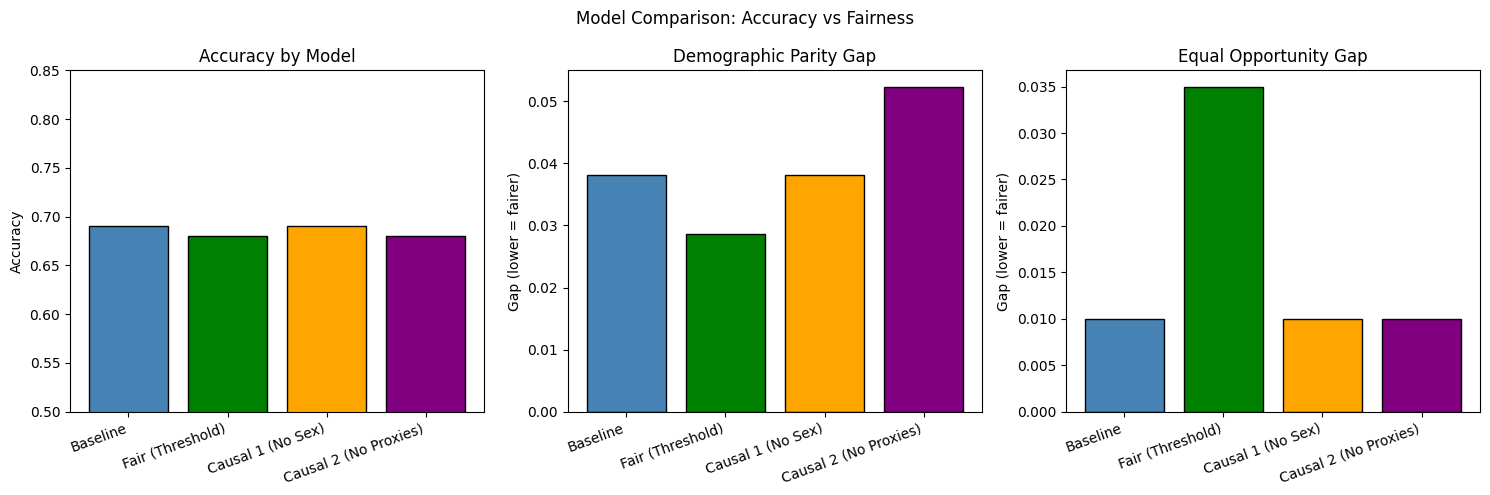

Saved: outputs/model_comparison.png


In [11]:
# Cell 11 - Visualizations
os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy
axes[0].bar(summary["Model"], summary["Accuracy"],
            color=["steelblue","green","orange","purple"],
            edgecolor="black")
axes[0].set_title("Accuracy by Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticklabels(summary["Model"], rotation=20, ha="right")
axes[0].set_ylim(0.5, 0.85)

# Parity Gap
axes[1].bar(summary["Model"], summary["Parity Gap"],
            color=["steelblue","green","orange","purple"],
            edgecolor="black")
axes[1].set_title("Demographic Parity Gap")
axes[1].set_ylabel("Gap (lower = fairer)")
axes[1].set_xticklabels(summary["Model"], rotation=20, ha="right")

# EO Gap
axes[2].bar(summary["Model"], summary["EO Gap"],
            color=["steelblue","green","orange","purple"],
            edgecolor="black")
axes[2].set_title("Equal Opportunity Gap")
axes[2].set_ylabel("Gap (lower = fairer)")
axes[2].set_xticklabels(summary["Model"], rotation=20, ha="right")

plt.suptitle("Model Comparison: Accuracy vs Fairness")
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150)
plt.show()
print("Saved: outputs/model_comparison.png")

In [12]:
# Cell 12 - Save CSV and Models
summary.to_csv("outputs/model_comparison.csv", index=False)
print("Saved: outputs/model_comparison.csv")

joblib.dump(baseline, "models/logistic_model.pkl")
joblib.dump(imputer,  "models/imputer.pkl")
joblib.dump(scaler,   "models/scaler.pkl")

with open("models/fair_thresholds.json", "w") as f:
    json.dump({"female": female_threshold, "male": male_threshold}, f)

print("Models saved.")

Saved: outputs/model_comparison.csv
Models saved.


In [15]:
# Save all models
import os
os.makedirs("models", exist_ok=True)

# Baseline model (used for both baseline and fair threshold predictions)
joblib.dump(baseline, "models/logistic_model.pkl")
joblib.dump(imputer,  "models/imputer.pkl")
joblib.dump(scaler,   "models/scaler.pkl")

# Causal models
joblib.dump(model_c1, "models/causal_model_1.pkl")
joblib.dump(model_c2, "models/causal_model_2.pkl")
joblib.dump(imp_c1,   "models/imputer_c1.pkl")
joblib.dump(sc_c1,    "models/scaler_c1.pkl")

# Fair thresholds
import json
with open("models/fair_thresholds.json", "w") as f:
    json.dump({"female": female_threshold, "male": male_threshold}, f)

# Summary CSV
summary.to_csv("outputs/model_comparison.csv", index=False)

print("All models saved.")
print("Files in models/:", os.listdir("models"))

All models saved.
Files in models/: ['causal_model_1.pkl', 'causal_model_2.pkl', 'confusion_matrix.png', 'fairness_by_sex.png', 'fair_model.pkl', 'fair_thresholds.json', 'feature_names.pkl', 'imputer.pkl', 'imputer_c1.pkl', 'logistic_model.pkl', 'random_forest.pkl', 'scaler.pkl', 'scaler_c1.pkl']


In [16]:
import os
print(os.getcwd())
print("baseline classes:", baseline.classes_)
print("baseline accuracy:", baseline_acc)

e:\causal-fairness-credit-scoring\causal-fairness-credit-scoring
baseline classes: ['bad' 'good']
baseline accuracy: 0.69
